In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
df = pd.read_csv('../../../data/processed/final_dataset.csv')
df.head()

,sustainability_score,total_renewal_score_new,last_years_price,auto_renewal_score,status_scores,anchoring_score,tenure_scores,proforma_auto_renewal,proforma_world_pay_token,proforma_date,current_anchorings,payment_timeframe,registration_date,proforma_audit_status,renewal_score_at_release,proforma_approved_lists,tenure_years,prospect_renewal_date,starting_net,starting_vat,starting_gross,starting_membership_net,starting_package_net,starting_pqq_net,membership_net,package_net,pqqnet,total_amount,last_renewal,last_total_net_paid,last_connections,renewal_year,is_first_year,has_discount,discount_pct,price_increase_abs,price_increase_pct,price_increased_flag,band_ordinal,last_band_ordinal,band_changed,band_upgraded,band_downgraded,tenure_group_ordinal,anchor_group_ordinal,membership_status_ordinal,has_auto_renewal,has_world_pay_token,payment_method_bacs,payment_method_card,payment_method_cheque,payment_method_unknown,payment_method_world_pay,proforma_account_stage_membership_only,proforma_account_stage_published,proforma_account_stage_renewal_process,proforma_account_stage_retired,proforma_account_stage_suspended,proforma_account_stage_unknown,proforma_account_stage_vetting,churn,rc_14d_total_calls,rc_14d_inbound_calls,rc_14d_max_call_number,membership_renewal_decision,desire_to_cancel_encoded,customer_response_encoded,serious_complaint,other_complaint,complaint_count,discussion_on_price_increase,renewal_impact_due_to_price_increase,discount_or_waiver_requested,discount_offered,price_pressure_flag,price_range_discussed_flag,percentage_price_increase_mentioned,monetary_price_increase_mentioned,explicit_competitor_mention,explicit_switching_intent,mentioned_competitors,price_switching_mentioned,competitor_better_value,competitor_similar_value,competitor_better_service,competitor_cheaper,competitor_signal_count,competitor_threat_flag,agent_renewal_initiation,agent_flagged_membership_status_alert,agent_active_retention,call_reschedule_request,topic_by_customer,topic_by_agent,customer_asked_for_justification,rc_high_risk_call,rc_14d_outbound_calls,crm_sentiment_encoded,crm_dissatisfied_flag,crm_satisfied_flag,crm_contractor_sentiment_score,crm_delays_in_accreditation,crm_contractor_suggested_leave,crm_competitors_mentioned,crm_platform_issues_raised,crm_membership_overdue,crm_dissatisified_with_renewal_price,crm_customer_complained,crm_refund_mentioned,crm_negative_customer_experience,crm_dissatisfaction_with_support,crm_financial_hardship_mentioned,crm_dts_or_ssip_mentioned,crm_accreditation_completed,crm_timely_completion,crm_progress_towards_accreditation,crm_contractor_engagement,crm_customer_payment_intention,crm_agent_chased_contractor,crm_accreditation_issues,crm_agent_chase_count,crm_auto_renewal_status,crm_membership_level_ordinal,high_risk_email,emails_dissatisfaction_issue_count,engagement_score,sentiment_score_valid,email_count,cc_calls_14d_total_calls,cc_calls_14d_inbound_calls,cc_sentiment_encoded,cc_dissatisfied_flag,cc_contractor_sentiment_start_score,cc_contractor_sentiment_end_score,cc_contractor_sentiment_overall_score,cc_customer_issues_concerns,cc_business_struggles_financial_hardship,cc_login_issues,cc_platform_issues,cc_dissatisfaction_time_to_complete,cc_process_complexity_concerns,cc_questions_harder_than_expected,cc_dissatisfaction_support,cc_pricing_mentioned,cc_pricing_sentiment_impact,cc_refund_discussed,cc_contractor_suggest_leave,cc_contractor_complained,cc_urgency_getting_on_site,cc_chasing_response,cc_questionnaire_completion,cc_care_package_discussed,cc_external_consultant,cc_agent_cross_sell_attempt,cc_issues_within_questionnaire,sentiment_improved,sentiment_worsened,sentiment_change,cc_high_risk_call,cc_dissatisfaction_issue_count,pricing_pressure_flag,cc_care_package_assisted,cc_care_package_express,cc_care_package_not_discussed,cc_care_package_premier,cc_care_package_standard,cc_care_package_unknown,cc_call_initiated_by_agent,cc_call_initiated_by_customer,cc_call_initiated_by_not_relevant,cc_call_init

In [2]:
print(df.shape)
print(df["churn"].value_counts())

(113769, 175)
churn
0    101172
1     12597
Name: count, dtype: int64


In [3]:


# Calculate correlations with the 'churn' variable
correlations = df.corr(numeric_only=True)['churn'].sort_values(ascending=False)

print('Features correlated with churn (top 20 positive correlations):')
print(correlations.head(20))

print('\nFeatures correlated with churn (top 20 negative correlations):')
print(correlations.tail(20))


Features correlated with churn (top 20 positive correlations):
churn                                     1.000000
payment_method_unknown                    0.768344
discount_pct                              0.311491
has_discount                              0.266269
proforma_account_stage_membership_only    0.244535
crm_contractor_suggested_leave            0.224022
high_risk_email                           0.195712
membership_renewal_decision               0.150227
desire_to_cancel_encoded                  0.131835
price_increased_flag                      0.127737
rc_high_risk_call                         0.124418
crm_negative_customer_experience          0.117780
crm_financial_hardship_mentioned          0.116086
emails_dissatisfaction_issue_count        0.104557
is_first_year                             0.103514
crm_dissatisfied_flag                     0.102879
crm_auto_renewal_status                   0.097975
proforma_account_stage_vetting            0.094106
payment_timeframe  

In [4]:
print('\nDescriptive Statistics:')
display(df.describe())


Descriptive Statistics:


,sustainability_score,total_renewal_score_new,last_years_price,auto_renewal_score,status_scores,anchoring_score,tenure_scores,proforma_auto_renewal,proforma_world_pay_token,current_anchorings,payment_timeframe,renewal_score_at_release,proforma_approved_lists,tenure_years,starting_net,starting_vat,starting_gross,starting_membership_net,starting_package_net,starting_pqq_net,membership_net,package_net,pqqnet,total_amount,last_total_net_paid,last_connections,renewal_year,is_first_year,has_discount,discount_pct,price_increase_abs,price_increase_pct,price_increased_flag,band_ordinal,last_band_ordinal,band_changed,band_upgraded,band_downgraded,tenure_group_ordinal,anchor_group_ordinal,membership_status_ordinal,has_auto_renewal,has_world_pay_token,payment_method_bacs,payment_method_card,payment_method_cheque,payment_method_unknown,payment_method_world_pay,proforma_account_stage_membership_only,proforma_account_stage_published,proforma_account_stage_renewal_process,proforma_account_stage_retired,proforma_account_stage_suspended,proforma_account_stage_unknown,proforma_account_stage_vetting,churn,rc_14d_total_calls,rc_14d_inbound_calls,rc_14d_max_call_number,membership_renewal_decision,desire_to_cancel_encoded,customer_response_encoded,serious_complaint,other_complaint,complaint_count,discussion_on_price_increase,renewal_impact_due_to_price_increase,discount_or_waiver_requested,discount_offered,price_pressure_flag,price_range_discussed_flag,percentage_price_increase_mentioned,monetary_price_increase_mentioned,explicit_competitor_mention,explicit_switching_intent,mentioned_competitors,price_switching_mentioned,competitor_better_value,competitor_similar_value,competitor_better_service,competitor_cheaper,competitor_signal_count,competitor_threat_flag,agent_renewal_initiation,agent_flagged_membership_status_alert,agent_active_retention,call_reschedule_request,topic_by_customer,topic_by_agent,customer_asked_for_justification,rc_high_risk_call,rc_14d_outbound_calls,crm_sentiment_encoded,crm_dissatisfied_flag,crm_satisfied_flag,crm_contractor_sentiment_score,crm_delays_in_accreditation,crm_contractor_suggested_leave,crm_competitors_mentioned,crm_platform_issues_raised,crm_membership_overdue,crm_dissatisified_with_renewal_price,crm_customer_complained,crm_refund_mentioned,crm_negative_customer_experience,crm_dissatisfaction_with_support,crm_financial_hardship_mentioned,crm_dts_or_ssip_mentioned,crm_accreditation_completed,crm_timely_completion,crm_progress_towards_accreditation,crm_contractor_engagement,crm_customer_payment_intention,crm_agent_chased_contractor,crm_accreditation_issues,crm_agent_chase_count,crm_auto_renewal_status,crm_membership_level_ordinal,high_risk_email,emails_dissatisfaction_issue_count,engagement_score,sentiment_score_valid,email_count,cc_calls_14d_total_calls,cc_calls_14d_inbound_calls,cc_sentiment_encoded,cc_dissatisfied_flag,cc_contractor_sentiment_start_score,cc_contractor_sentiment_end_score,cc_contractor_sentiment_overall_score,cc_customer_issues_concerns,cc_business_struggles_financial_hardship,cc_login_issues,cc_platform_issues,cc_dissatisfaction_time_to_complete,cc_process_complexity_concerns,cc_questions_harder_than_expected,cc_dissatisfaction_support,cc_pricing_mentioned,cc_pricing_sentiment_impact,cc_refund_discussed,cc_contractor_suggest_leave,cc_contractor_complained,cc_urgency_getting_on_site,cc_chasing_response,cc_questionnaire_completion,cc_care_package_discussed,cc_external_consultant,cc_agent_cross_sell_attempt,cc_issues_within_questionnaire,sentiment_improved,sentiment_worsened,sentiment_change,cc_high_risk_call,cc_dissatisfaction_issue_count,pricing_pressure_flag,cc_care_package_assisted,cc_care_package_express,cc_care_package_not_discussed,cc_care_package_premier,cc_care_package_standard,cc_care_package_unknown,cc_call_initiated_by_agent,cc_call_initiated_by_customer,cc_call_initiated_by_not_relevant,cc_call_initiated_by_unknown,cc_calls_14d_outbound_calls,has_renewal_call,has_email,has_cc_call
count

In [5]:
print('\nMissing Values:')
display(df.isnull().sum())


Missing Values:


sustainability_score            0
total_renewal_score_new         0
last_years_price                0
auto_renewal_score              0
status_scores                   0
                               ..
cc_call_initiated_by_unknown    0
cc_calls_14d_outbound_calls     0
has_renewal_call                0
has_email                       0
has_cc_call                     0
Length: 175, dtype: int64

**HYPOTHESIS TESTING**

### Hypothesis Test 1: Discount Percentage

**H0:** The mean `discount_pct` is the same for churned and non-churned customers.

**H1:** The mean `discount_pct` differs between churned and non-churned customers.

**Test:** Independent samples t-test.

In [6]:
from scipy.stats import ttest_ind

discount_churn = df[df['churn'] == 1]['discount_pct']
discount_no_churn = df[df['churn'] == 0]['discount_pct']

t_stat, p_value = ttest_ind(discount_churn, discount_no_churn, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3e}")

T-statistic: 61.340
P-value: 0.000e+00


### Inference for Hypothesis Test 1

Given the extremely small p-value, we **Reject** the null hypothesis. This indicates there **is** a statistically significant difference in the mean `discount_pct` between churned and non-churned customers.

### Hypothesis Test 2: Tenure Years

**H0:** The mean `tenure_years` is the same for churned and non-churned customers.

**H1:** The mean `tenure_years` differs between churned and non-churned customers.

**Test:** Independent samples t-test.

In [7]:
from scipy.stats import ttest_ind

tenure_churn = df[df['churn'] == 1]['tenure_years']
tenure_no_churn = df[df['churn'] == 0]['tenure_years']

t_stat, p_value = ttest_ind(tenure_churn, tenure_no_churn, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3e}")

T-statistic: -67.037
P-value: 0.000e+00


### Inference for Hypothesis Test 2

Given the extremely small p-value, we **Reject** the null hypothesis. This indicates there **is** a statistically significant difference in the mean `tenure_years` between churned and non-churned customers.

### Hypothesis Test 3: Total Amount Paid

**H0:** The mean `total_amount` is the same for churned and non-churned customers.

**H1:** The mean `total_amount` differs between churned and non-churned customers.

**Test:** Independent samples t-test.

In [8]:
from scipy.stats import ttest_ind

total_amount_churn = df[df['churn'] == 1]['total_amount']
total_amount_no_churn = df[df['churn'] == 0]['total_amount']

t_stat, p_value = ttest_ind(total_amount_churn, total_amount_no_churn, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3e}")

T-statistic: -60.012
P-value: 0.000e+00


### Inference for Hypothesis Test 3

Given the extremely small p-value, we **Reject** the null hypothesis. This indicates there **is** a statistically significant difference in the mean `total_amount` between churned and non-churned customers.

### Hypothesis Test 4: Sustainability Score

**H0:** The mean `sustainability_score` is the same for churned and non-churned customers.

**H1:** The mean `sustainability_score` differs between churned and non-churned customers.

**Test:** Independent samples t-test.

In [9]:
from scipy.stats import ttest_ind

sustainability_churn = df[df['churn'] == 1]['sustainability_score']
sustainability_no_churn = df[df['churn'] == 0]['sustainability_score']

t_stat, p_value = ttest_ind(sustainability_churn, sustainability_no_churn, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3e}")

T-statistic: -257.911
P-value: 0.000e+00


### Inference for Hypothesis Test 4

Given the extremely small p-value, we **Reject** the null hypothesis. This indicates there **is** a statistically significant difference in the mean `sustainability_score` between churned and non-churned customers.

### Hypothesis Test 5: Payment Method (Unknown) and Churn

**H0:** `payment_method_unknown` is independent of `churn`.

**H1:** `payment_method_unknown` is associated with `churn`.

**Test:** Chi-squared test of independence.

In [10]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['payment_method_unknown'], df['churn'])
chi2, p_value, _, _ = chi2_contingency(contingency_table)

print(f"Chi-squared statistic: {chi2:.3f}")
print(f"P-value: {p_value:.3e}")

Chi-squared statistic: 67154.032
P-value: 0.000e+00


### Inference for Hypothesis Test 5

Given the extremely small p-value, we **Reject** the null hypothesis. This indicates there **is** a statistically significant association between `payment_method_unknown` and `churn`.

### Hypothesis Test 6: Desire to Cancel and Churn

**H0:** `desire_to_cancel_encoded` is independent of `churn`.

**H1:** `desire_to_cancel_encoded` is associated with `churn`.

**Test:** Chi-squared test of independence.

In [11]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['desire_to_cancel_encoded'], df['churn'])
chi2, p_value, _, _ = chi2_contingency(contingency_table)

print(f"Chi-squared statistic: {chi2:.3f}")
print(f"P-value: {p_value:.3e}")

Chi-squared statistic: 1973.037
P-value: 0.000e+00


### Inference for Hypothesis Test 6

Given the extremely small p-value, we **Reject** the null hypothesis. This indicates there **is** a statistically significant association between `desire_to_cancel_encoded` and `churn`.

### Hypothesis Test 7: High Risk Email and Churn

**H0:** `high_risk_email` is independent of `churn`.

**H1:** `high_risk_email` is associated with `churn`.

**Test:** Chi-squared test of independence.

In [12]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['high_risk_email'], df['churn'])
chi2, p_value, _, _ = chi2_contingency(contingency_table)

print(f"Chi-squared statistic: {chi2:.3f}")
print(f"P-value: {p_value:.3e}")

Chi-squared statistic: 4354.384
P-value: 0.000e+00


### Inference for Hypothesis Test 7

Given the extremely small p-value, we **Reject** the null hypothesis. This indicates there **is** a statistically significant association between `high_risk_email` and `churn`.

### Hypothesis Test 8: Customer Dissatisfaction and Churn

**H0:** `crm_dissatisfied_flag` is independent of `churn`.

**H1:** `crm_dissatisfied_flag` is associated with `churn`.

**Test:** Chi-squared test of independence.

In [13]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['crm_dissatisfied_flag'], df['churn'])
chi2, p_value, _, _ = chi2_contingency(contingency_table)

print(f"Chi-squared statistic: {chi2:.3f}")
print(f"P-value: {p_value:.3e}")

Chi-squared statistic: 1201.209
P-value: 3.330e-263


### Inference for Hypothesis Test 8

Given the extremely small p-value, we **Reject** the null hypothesis. This indicates there **is** a statistically significant association between `crm_dissatisfied_flag` and `churn`.

### Hypothesis Test 9: Price Increase Impact and Churn

**H0:** `price_increased_flag` is independent of `churn`.

**H1:** `price_increased_flag` is associated with `churn`.

**Test:** Chi-squared test of independence.

In [14]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['price_increased_flag'], df['churn'])
chi2, p_value, _, _ = chi2_contingency(contingency_table)

print(f"Chi-squared statistic: {chi2:.3f}")
print(f"P-value: {p_value:.3e}")

Chi-squared statistic: 1855.307
P-value: 0.000e+00


### Inference for Hypothesis Test 9

Given the extremely small p-value, we **Reject** the null hypothesis. This indicates there **is** a statistically significant association between `price_increased_flag` and `churn`.

### Hypothesis Test 10: Auto Renewal and Churn

**H0:** `has_auto_renewal` is independent of `churn`.

**H1:** `has_auto_renewal` is associated with `churn`.

**Test:** Chi-squared test of independence.

In [15]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['has_auto_renewal'], df['churn'])
chi2, p_value, _, _ = chi2_contingency(contingency_table)

print(f"Chi-squared statistic: {chi2:.3f}")
print(f"P-value: {p_value:.3e}")

Chi-squared statistic: 2405.615
P-value: 0.000e+00


### Inference for Hypothesis Test 10

Given the extremely small p-value, we **Reject** the null hypothesis. This indicates there **is** a statistically significant association between `has_auto_renewal` and `churn`.

###  Data Leakage Mitigation

The following columns are being dropped due to potential data leakage, as they represent information that would likely only be available during or after the renewal process:

*   `membership_renewal_decision`
*   `total_renewal_score_new`
*   `status_scores`
*   `renewal_score_at_release`
*   `membership_status_ordinal`
*   `auto_renewal_score`

In [16]:
import numpy as np
from sklearn.model_selection import train_test_split

# Columns identified as potential data leakage
leakage_cols = [
    "total_renewal_score_new",
    "status_scores",
    "renewal_score_at_release",
    "membership_status_ordinal",
    "auto_renewal_score"
]

# Drop leakage columns
df = df.drop(columns=leakage_cols, errors="ignore")
print(df.shape)


(113769, 170)


**DATA SPLIT**

In [17]:
X = df.drop(columns=["churn"])

# keep only numeric columns
X = X.select_dtypes(include=[np.number])

y = df["churn"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(91015, 164) (22754, 164)


In [18]:
# from sklearn.model_selection import train_test_split

# X = df.drop(columns=["churn"])
# y = df["churn"]

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )

# print(X_train.shape, X_test.shape)

In [19]:
# Sanity check for Stratified sampling
print("Train churn ratio:")
print(y_train.value_counts(normalize=True))

print("\nTest churn ratio:")
print(y_test.value_counts(normalize=True))

Train churn ratio:
churn
0    0.889271
1    0.110729
Name: proportion, dtype: float64

Test churn ratio:
churn
0    0.889294
1    0.110706
Name: proportion, dtype: float64


### Logistic Regression Model

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("LR ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print(classification_report(y_test, y_pred_lr))

LR ROC-AUC: 0.9662714984599868
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     20235
           1       0.53      0.90      0.66      2519

    accuracy                           0.90     22754
   macro avg       0.76      0.90      0.80     22754
weighted avg       0.94      0.90      0.91     22754



c:\Users\gopik\Downloads\ds_mini_project\churn-prediction-project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Random Forest Classifier Model

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("RF ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

RF ROC-AUC: 0.9986133946376208
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     20235
           1       0.89      0.98      0.93      2519

    accuracy                           0.98     22754
   macro avg       0.94      0.98      0.96     22754
weighted avg       0.99      0.98      0.99     22754



### XGBoost Classifier Model

In [22]:
from xgboost import XGBClassifier

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("XGB ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print(classification_report(y_test, y_pred_xgb))

XGB ROC-AUC: 0.9998538019870334
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20235
           1       0.97      1.00      0.98      2519

    accuracy                           1.00     22754
   macro avg       0.99      1.00      0.99     22754
weighted avg       1.00      1.00      1.00     22754



### Model Performance Comparison

In [23]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

# Logistic Regression
lr_auc = roc_auc_score(y_test, y_prob_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

# Random Forest
rf_auc = roc_auc_score(y_test, y_prob_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

# XGBoost
xgb_auc = roc_auc_score(y_test, y_prob_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

# Create comparison table
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC-AUC": [lr_auc, rf_auc, xgb_auc],
    "Precision": [lr_precision, rf_precision, xgb_precision],
    "Recall": [lr_recall, rf_recall, xgb_recall],
    "F1-Score": [lr_f1, rf_f1, xgb_f1]
})

print(comparison)

                 Model   ROC-AUC  Precision    Recall  F1-Score
0  Logistic Regression  0.966271   0.525341  0.901151  0.663743
1        Random Forest  0.998613   0.892302  0.980151  0.934166
2              XGBoost  0.999854   0.972868  0.996427  0.984507


## Model Explainability and Feature Importance

To understand *why* our churn prediction models are making their decisions, we'll delve into **model explainability**. This involves two key approaches:

1.  **SHAP Analysis (SHapley Additive exPlanations)**: We'll apply SHAP to our best-performing XGBoost model. This technique helps us understand how each feature contributes to an individual prediction, showing not only the magnitude but also the direction of its impact on the churn probability.

2.  **Traditional Feature Importance**: We will also examine feature importance directly from both the Logistic Regression and XGBoost models:
    *   For **Logistic Regression**, we'll analyze the coefficients, indicating the strength and direction of the relationship between each feature and the log-odds of churn.
    *   For **XGBoost**, we'll use its built-in `feature_importances_` attribute, quantifying how much each feature contributes to the model's overall predictive power.

### SHAP Analysis (XGBoost)

SHAP provides insights into how features influence the XGBoost model's predictions. The summary plots show overall feature importance and how individual feature values push predictions towards or away from churn.

c:\Users\gopik\Downloads\ds_mini_project\churn-prediction-project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



SHAP Summary Plot (Feature Importance and Direction of Impact):


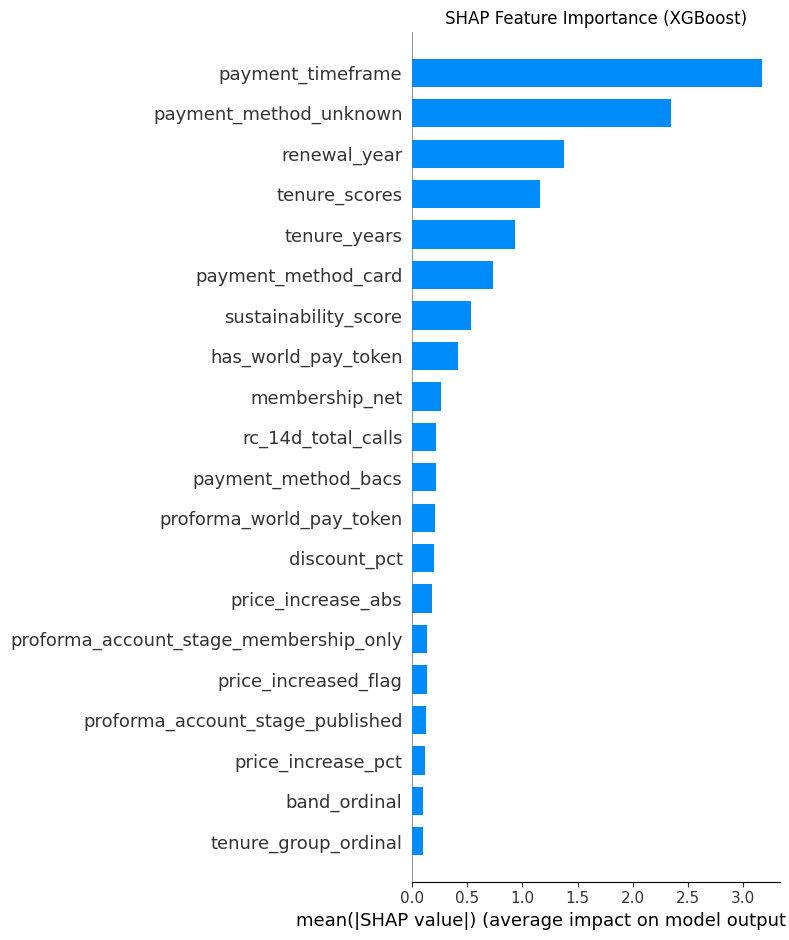

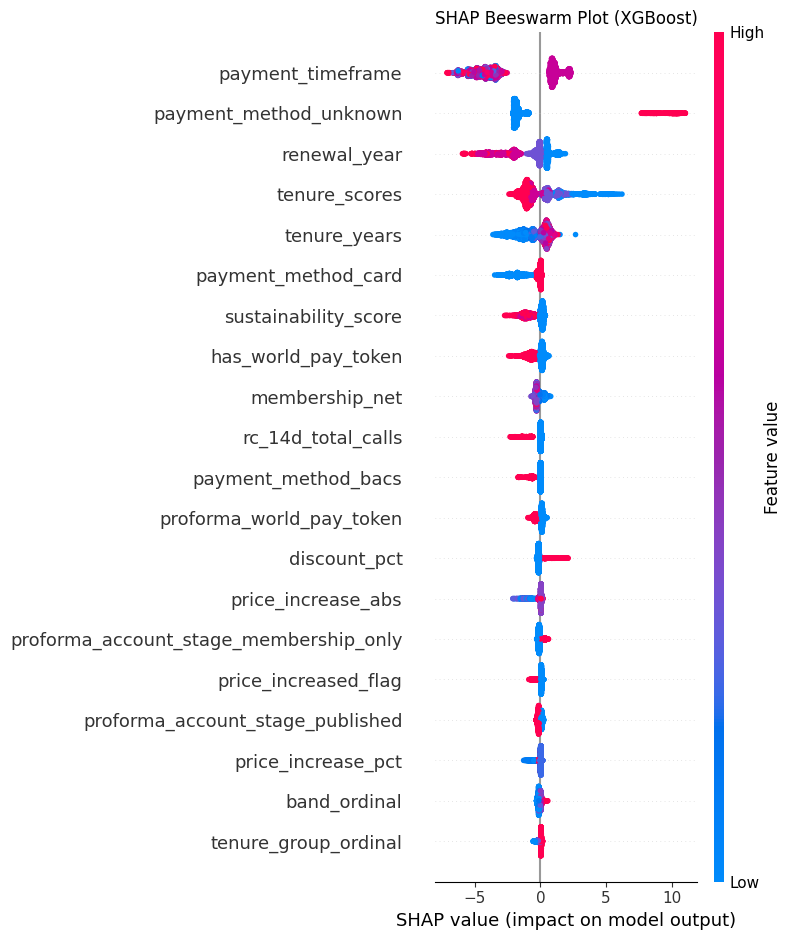

In [25]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sample_size = 5000
if X_test.shape[0] > sample_size:
    X_test_sampled = X_test.sample(n=sample_size, random_state=42)
else:
    X_test_sampled = X_test

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_sampled)

print("\nSHAP Summary Plot (Feature Importance and Direction of Impact):")
shap.summary_plot(shap_values, X_test_sampled, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (XGBoost)')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_test_sampled, show=False)
plt.title('SHAP Beeswarm Plot (XGBoost)')
plt.tight_layout()
plt.show()


SHAP Dependence Plots for Top Features:


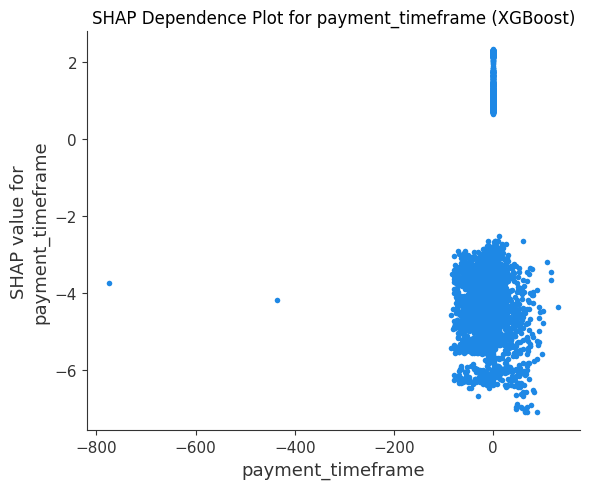

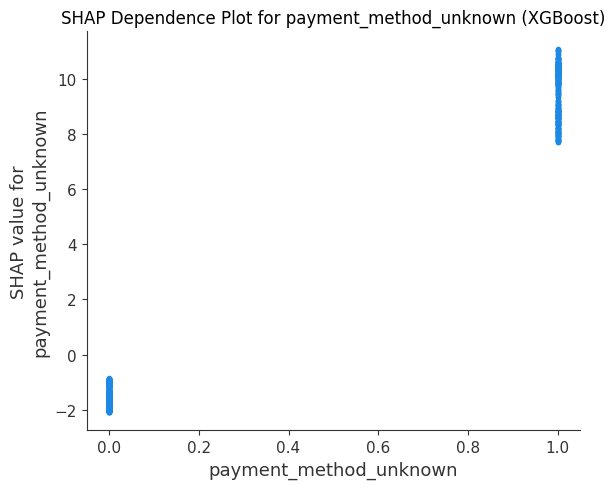

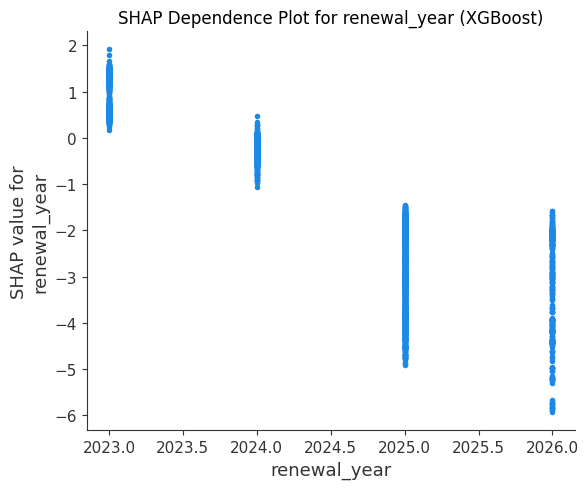

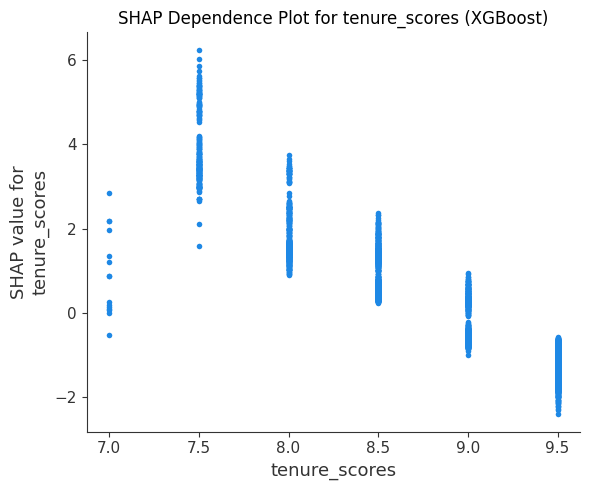

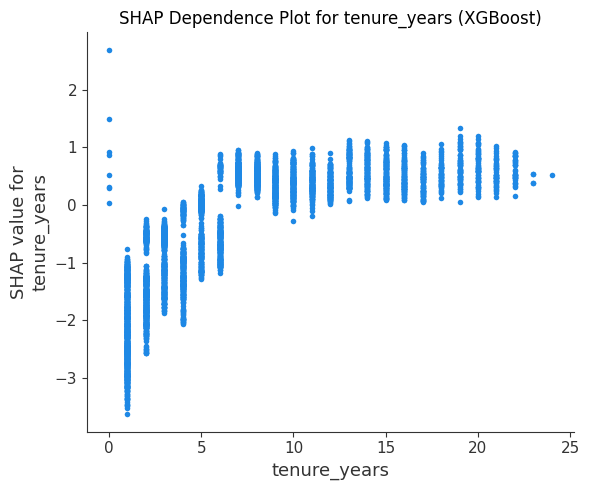

In [26]:
print("\nSHAP Dependence Plots for Top Features:")

if isinstance(shap_values, list):
    abs_shap_values = np.abs(shap_values[1])
else:
    abs_shap_values = np.abs(shap_values)

feature_importance_shap = pd.DataFrame({
    'feature': X_test_sampled.columns,
    'shap_abs_mean': abs_shap_values.mean(axis=0)
}).sort_values(by='shap_abs_mean', ascending=False)

top_features_shap = feature_importance_shap['feature'].head(5).tolist()

for feature in top_features_shap:
    if isinstance(shap_values, list):
        shap.dependence_plot(feature, shap_values[1], X_test_sampled, interaction_index=None, show=False)
    else:
        shap.dependence_plot(feature, shap_values, X_test_sampled, interaction_index=None, show=False)
    plt.title(f'SHAP Dependence Plot for {feature} (XGBoost)')
    plt.tight_layout()
    plt.show()

### Traditional Feature Importance

Here, we examine feature importance from Logistic Regression coefficients and XGBoost's built-in feature importance scores.

In [27]:
print("\nLogistic Regression Feature Importance (Absolute Coefficients):")

lr_coefficients = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr.coef_[0]
}).sort_values(by='coefficient', ascending=False)

print('\nTop 10 Positive Coefficients:')
display(lr_coefficients.head(10))

print('\nTop 10 Negative Coefficients:')
display(lr_coefficients.tail(10))

abs_lr_coefficients = lr_coefficients.copy()
abs_lr_coefficients['coefficient'] = abs_lr_coefficients['coefficient'].abs()
print('\nTop 10 Absolute Coefficients (Overall Importance):')
display(abs_lr_coefficients.sort_values(by='coefficient', ascending=False).head(10))


Logistic Regression Feature Importance (Absolute Coefficients):

Top 10 Positive Coefficients:


,feature,coefficient
41,payment_method_unknown,1.863804
43,proforma_account_stage_membership_only,0.631287
113,emails_dissatisfaction_issue_count,0.405224
112,high_risk_email,0.298033
109,crm_agent_chase_count,0.284208
8,proforma_approved_lists,0.279675
91,crm_contractor_suggested_leave,0.267169
162,has_email,0.203844
116,email_count,0.203690
24,has_discount,0.188714



Top 10 Negative Coefficients:


,feature,coefficient
6,current_anchorings,-0.292143
2,anchoring_score,-0.383557
27,price_increase_pct,-0.417653
5,proforma_world_pay_token,-0.420849
44,proforma_account_stage_published,-0.725722
38,payment_method_bacs,-0.789400
39,payment_method_card,-1.011765
37,has_world_pay_token,-1.232832
3,tenure_scores,-1.236692
0,sustainability_score,-1.663403



Top 10 Absolute Coefficients (Overall Importance):


,feature,coefficient
41,payment_method_unknown,1.863804
0,sustainability_score,1.663403
3,tenure_scores,1.236692
37,has_world_pay_token,1.232832
39,payment_method_card,1.011765
38,payment_method_bacs,0.789400
44,proforma_account_stage_published,0.725722
43,proforma_account_stage_membership_only,0.631287
5,proforma_world_pay_token,0.420849
27,price_increase_pct,0.417653



XGBoost Feature Importance:


,feature,importance
41,payment_method_unknown,0.368708
7,payment_timeframe,0.214726
22,renewal_year,0.069292
23,is_first_year,0.053243
37,has_world_pay_token,0.040155
38,payment_method_bacs,0.035848
0,sustainability_score,0.031204
39,payment_method_card,0.030513
42,payment_method_world_pay,0.020506
91,crm_contractor_suggested_leave,0.019082


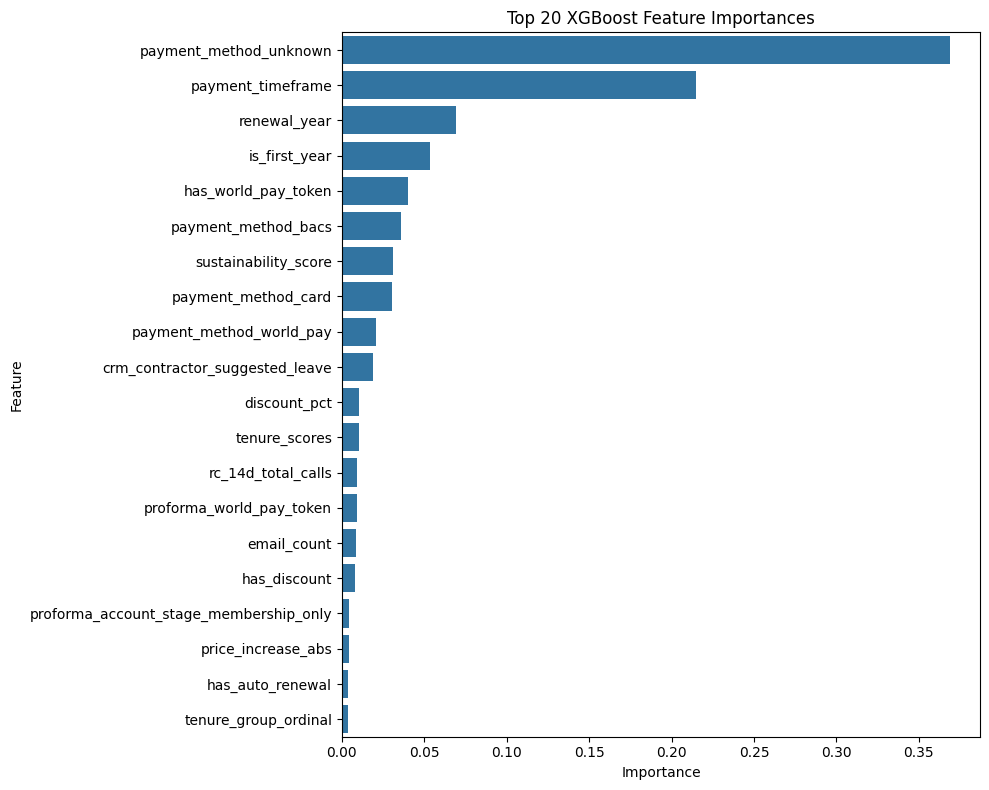

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

print("\nXGBoost Feature Importance:")

xgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb.feature_importances_
}).sort_values(by='importance', ascending=False)

display(xgb_importance.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=xgb_importance.head(20))
plt.title('Top 20 XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Model Performance: ROC Curve Comparison

This plot compares the ROC (Receiver Operating Characteristic) curves for the Logistic Regression, Random Forest, and XGBoost models. A higher AUC (Area Under the Curve) indicates better model performance in distinguishing between the positive (churned) and negative (non-churned) classes. The curve illustrates the trade-off between the True Positive Rate (Sensitivity) and the False Positive Rate (1-Specificity) at various threshold settings.

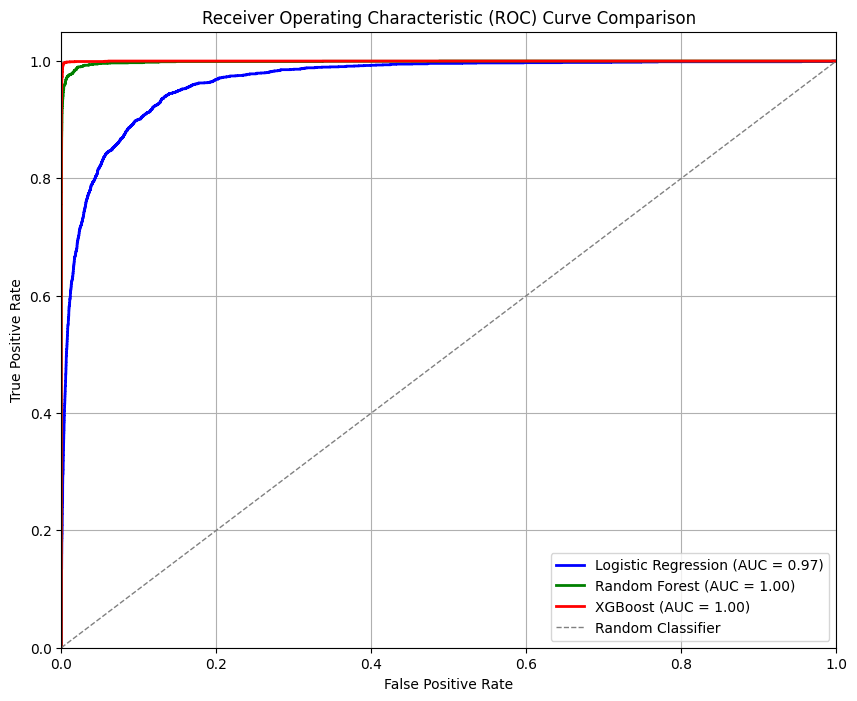

In [29]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Plot ROC for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')

# Plot ROC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

# Plot ROC for XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, color='red', lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()